In [2]:
import mne
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
from scipy.signal import detrend, welch 
import os
import pandas as pd 
import numpy as np

In [9]:
sub = "20"
ses = "01"
task = "experience4"

base_path = r"D:\Thesis\ThesisEEG\data\processed"
fif_path = fr"{base_path}\sub-{sub}_ses-{ses}_task-{task}_eeg_clean_raw.fif"

raw = mne.io.read_raw_fif(fif_path, preload=True)
if "Status" in raw.ch_names:
    raw.drop_channels(["Status"])

Opening raw data file D:\Thesis\ThesisEEG\data\processed\sub-20_ses-01_task-experience4_eeg_clean_raw.fif...
    Range : 0 ... 416395 =      0.000 ...   416.395 secs
Ready.
Reading 0 ... 416395  =      0.000 ...   416.395 secs...


In [10]:
#epochs = mne.make_fixed_length_epochs(
    #raw,
    #duration=1.0,  
    #overlap=0.0,
    #preload=True
#)

In [ ]:
sfreq = 400 #Todo: change to 400
win = 1
data = raw.get_data()
freqs, psd = welch(data, fs=sfreq, nperseg=sfreq*win, window='hamming', axis=1)
freqres = freqs[1] - freqs[0]
freq_bands = {
    'Alpha2': (10, 12)}
    

NameError: name 'raw' is not defined

In [13]:
relative_bandpower = {}

# Compute total power per channel
total_power = np.trapz(psd, freqs, axis=1)  

# Compute band powers
for band, (f_low, f_high) in freq_bands.items():
    idx = (freqs >= f_low) & (freqs <= f_high)
    band_power = np.trapz(psd[:, idx], freqs[idx], axis=1)  
    rel_power = band_power / total_power  # (n_channels,)
    relative_bandpower[band] = rel_power   #.mean()  

# Print results
print("Relative Bandpower:")
for band, value in relative_bandpower.items():
    print(f"{band}: min={value.min():.4f}, max={value.max():.4f}, std={value.std():.4f}")

Relative Bandpower:
Alpha2: min=0.0002, max=0.0991, std=0.0240


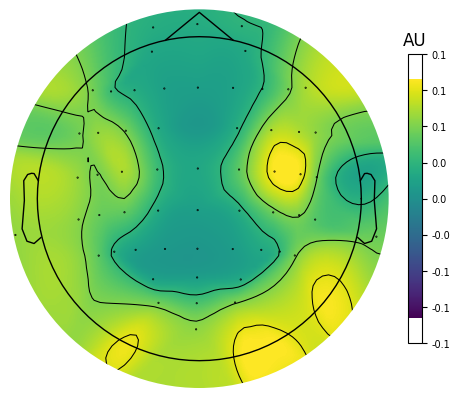

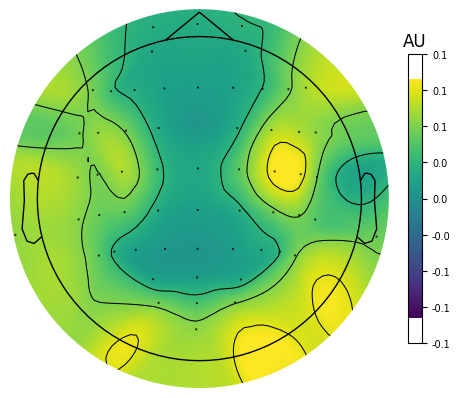

In [15]:
alpha2_rel = relative_bandpower["Alpha2"]   # or "Alpha" depending on your dict

evoked_rel = mne.EvokedArray(
    alpha2_rel[:, np.newaxis],   # shape (n_channels, 1)
    raw.info,
    tmin=0
)

evoked_rel.plot_topomap(
    times=0,
    ch_type='eeg',
    cmap='viridis',
    contours=6,
    scalings=dict(eeg=1),
    time_format='',
    size=3
)